# DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised clustering algorithm that identifies clusters as areas of high point density and labels points in sparse areas as noise.

The algorithm requires two main parameters:

 - $\epsilon$: The maximum distance between two points for them to be considered neighbors.

 - min_samples: The minimum number of neighbors a point must have (including itself) to be considered a core point.

DBSCAN works as follows:

#### Find neighbours

For each point in the dataset find all points within a distance of $\epsilon$ (these are its neighbours).

#### Classify the point:

- Core Point: If it has at least min_samples neighbors.

- Border Point: If it has fewer than min_samples neighbors but is within the neighborhood of a core point.

- Noise Point: If it has fewer than min_samples neighbors and is not within any core point's neighborhood.

#### Form clusters:

For each unvisited core point, start a new cluster.

Recursively add all density-reachable points (neighbors of neighbors) to the cluster.

#### Repeat! 

until all points are visited and either assigned to a cluster or labeled as noise.

A key advantage of this method is that clusters could have any shape rather than being circular.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from collections import deque
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import DBSCAN as SklearnDBSCAN

We’ll use the Breast Cancer Wisconsin dataset from sklearn.datasets

This dataset contains information about tumors, including whether they are malignant or benign, based on various features extracted from cell nuclei.

For simplicity and visualization purposes, we’ll focus on just two features:

- Mean Radius

- Mean Texture

These features create a 2D feature space, where we can visually inspect how the DBSCAN works on the data. While this visualization choice limits the full predictive power of the dataset, it allows us to clearly observe the decision boundaries and interpret the classification results. 

While for other methods I used all 30 features for fitting, for this particular method that hurts the accuracy of DBSCAN. THerefore for this one only, I only used the 2 features mentioned above for the analysis.

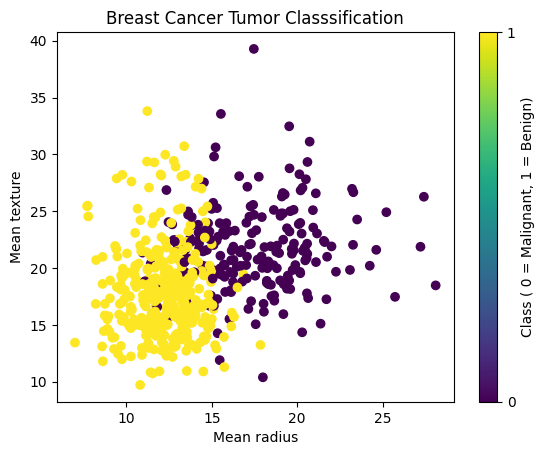

In [20]:
#Loading data
data = load_breast_cancer()
X, y = data.data, data.target
X = X[:,:2]

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')  # Pick two features to plot
plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')

plt.show()

In [21]:
class SimpleDBSCAN:
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None

    def fit(self, X):
        n_samples = X.shape[0]
        self.labels_ = np.full(n_samples, -1)  # Initialize all points as noise
        cluster_id = 0

        # Keep track of visited points
        visited = np.zeros(n_samples, dtype=bool)

        for point_idx in range(n_samples):
            if visited[point_idx]:
                continue

            visited[point_idx] = True
            neighbors = self._region_query(X, point_idx)

            if len(neighbors) < self.min_samples:
                # Noise (already labeled as -1)
                continue

            # Start a new cluster
            self._expand_cluster(X, point_idx, neighbors, cluster_id, visited)
            cluster_id += 1

    def _expand_cluster(self, X, point_idx, neighbors, cluster_id, visited):
        # Assign the cluster label
        self.labels_[point_idx] = cluster_id

        queue = deque(neighbors)
        while queue:
            neighbor_idx = queue.popleft()

            if not visited[neighbor_idx]:
                visited[neighbor_idx] = True
                neighbor_neighbors = self._region_query(X, neighbor_idx)
                if len(neighbor_neighbors) >= self.min_samples:
                    queue.extend(neighbor_neighbors)

            # Assign cluster label if not already assigned
            if self.labels_[neighbor_idx] == -1:
                self.labels_[neighbor_idx] = cluster_id

    def _region_query(self, X, point_idx):
        # Return all points within eps distance of point_idx
        distances = np.linalg.norm(X - X[point_idx], axis=1)
        return np.where(distances <= self.eps)[0]

In [22]:
#Scalling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 

In [23]:
# Implementing custom DBSCAN
custom_dbscan = SimpleDBSCAN(eps=0.5, min_samples=5)
custom_dbscan.fit(X_scaled)
custom_labels = custom_dbscan.labels_
ari_custom = adjusted_rand_score(y, custom_labels)
print(f"Custom DBSCAN ARI: {ari_custom:.4f}")

Custom DBSCAN ARI: 0.0338


In [29]:
#Implementing sklearn DBSCAN
sklearn_dbscan = SklearnDBSCAN(eps=0.5, min_samples=5)
sklearn_dbscan.fit(X_scaled)
sklearn_labels = sklearn_dbscan.labels_
ari_sklearn = adjusted_rand_score(y, sklearn_labels)
print(f"Scikit-learn DBSCAN ARI: {ari_sklearn:.4f}")

Scikit-learn DBSCAN ARI: 0.0338


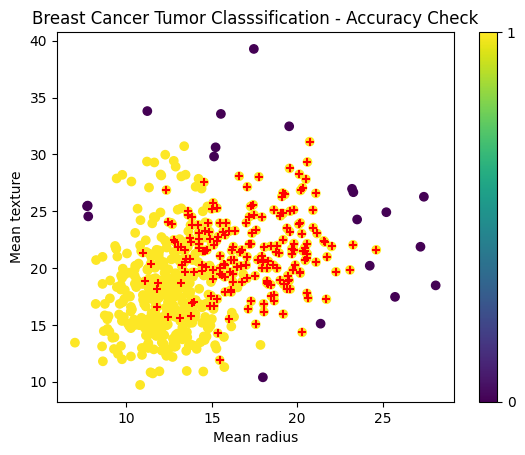

In [30]:
mismatch = custom_labels!= y

#It is hard to know which cluster is which, but for this dataset, accuracy is lower than 0.5, so if the "mismatches" are too few, the labels are probably flipped!
if (mismatch).sum() > len(y)/2:
    mismatch = custom_labels == y

# Plot all points by predicted cluster
scatter = plt.scatter(X[:, 0], X[:, 1], c=custom_labels, cmap='viridis', label='Cluster')

# Overlay mismatched points with red '+'
plt.scatter(X[mismatch, 0], X[mismatch, 1], marker='+', c='red', label='Mismatch')

plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification - Accuracy Check')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])

This method does not perform nearly as well as the other ones explored. The ARI value found is not super exciting, though it matches that of the sklearn implementation.

At first, the analysis was run with the 30 parameters, but the ARI score was 0 for that. This made me reduce that number to 2 and recalculate. It would be interesting to run a more thorough variation of parameters in future analysis to try to bring this value up, though this might just be a case in which the model is just not the most appropriate for the dataset.